# Retail Sales Analysis

End-to-end analysis of ~1,000,000 e-commerce transactions from a UK-based online retailer (**Online Retail II**, 2009-2011).

This notebook covers the full workflow of a data analyst:

1. **Load** the raw transactional data
2. **Clean & transform** it with pandas (the messy part: cancellations, returns, missing IDs, duplicates)
3. **Compute KPIs** (revenue, orders, average order value, customers)
4. **Visualise** trends, top products, markets, and customer behaviour with Matplotlib
5. **Summarise insights** for a non-technical stakeholder

**Dataset:** Online Retail II - UCI Machine Learning Repository / Kaggle. Download `online_retail_II.xlsx` into the `./data/` folder before running.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = Path("data")
RAW_FILE = DATA_DIR / "online_retail_II.xlsx"   # change if you downloaded a CSV

# UCI column headers. If your download differs, these get renamed.
RENAME_MAP = {"InvoiceNo": "Invoice", "UnitPrice": "Price", "CustomerID": "Customer ID"}

## 2. Load the raw data

The Excel version ships two sheets (2009-2010 and 2010-2011), so we concatenate them into one table.

In [2]:
def load_raw(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Raw data not found at {path}. Download 'Online Retail II' from UCI / Kaggle "
            "and place it in the ./data/ folder."
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        sheets = pd.read_excel(path, sheet_name=None)      # dict of DataFrames
        df = pd.concat(sheets.values(), ignore_index=True)
    else:
        df = pd.read_csv(path, encoding="ISO-8859-1")
    return df.rename(columns=RENAME_MAP)


raw = load_raw(RAW_FILE)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Raw shape: 1,067,371 rows x 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Quick quality check: dtypes and missing values
raw.info()
print("\nMissing values per column:")
print(raw.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Missing values per column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


## 3. Data cleaning & transformation

Raw transaction exports are messy. We apply the following steps and track how many rows each removes:

1. Drop rows missing a `Customer ID` or `Description`
2. Remove cancelled orders (invoice starts with `C`)
3. Keep only real sales (`Quantity > 0` and `Price > 0`)
4. Drop exact duplicate rows
5. Parse dates and derive `Year`, `Month`, `YearMonth`, `Weekday`
6. Compute `Revenue = Quantity x Price`
7. Standardise text and tidy types

In [4]:
df = raw.copy()
rows_start = len(df)

# 1. Missing customer / description
df = df.dropna(subset=["Customer ID", "Description"])

# 2. Cancellations
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# 3. Real sales only
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

# 4. Duplicates
df = df.drop_duplicates()

# 5. Date parts
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["Weekday"] = df["InvoiceDate"].dt.day_name()

# 6. Revenue
df["Revenue"] = df["Quantity"] * df["Price"]

# 7. Tidy text + types
df["Description"] = df["Description"].str.strip()
df["Country"] = df["Country"].str.strip()
df["Customer ID"] = df["Customer ID"].astype(np.int64)

print(f"Rows: {rows_start:,} -> {len(df):,} ({rows_start - len(df):,} removed)")
df.head()

Rows: 1,067,371 -> 779,425 (287,946 removed)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,YearMonth,Weekday,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,2009-12,Tuesday,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,2009-12,Tuesday,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,2009-12,Tuesday,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,2009-12,Tuesday,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,2009-12,Tuesday,30.0


In [5]:
# Save the clean dataset so it can be reused (e.g. in Power BI or further work)
clean_path = DATA_DIR / "online_retail_clean.csv"
df.to_csv(clean_path, index=False)
print(f"Clean dataset written to {clean_path} ({len(df):,} rows)")

Clean dataset written to data\online_retail_clean.csv (779,425 rows)


## 4. Key performance indicators (KPIs)

In [6]:
orders = df.groupby("Invoice")["Revenue"].sum()

kpis = {
    "Total revenue": df["Revenue"].sum(),
    "Total orders": df["Invoice"].nunique(),
    "Unique customers": df["Customer ID"].nunique(),
    "Average order value": orders.mean(),
    "Average items per order": df.groupby("Invoice")["Quantity"].sum().mean(),
}

print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}\n")
for name, value in kpis.items():
    print(f"{name:<24}: {value:>14,.2f}")

Date range: 2009-12-01 to 2011-12-09

Total revenue           :  17,374,804.27
Total orders            :      36,969.00
Unique customers        :       5,878.00
Average order value     :         469.98
Average items per order :         284.40


## 5. Revenue trend over time

How does monthly revenue evolve across the two-year period?

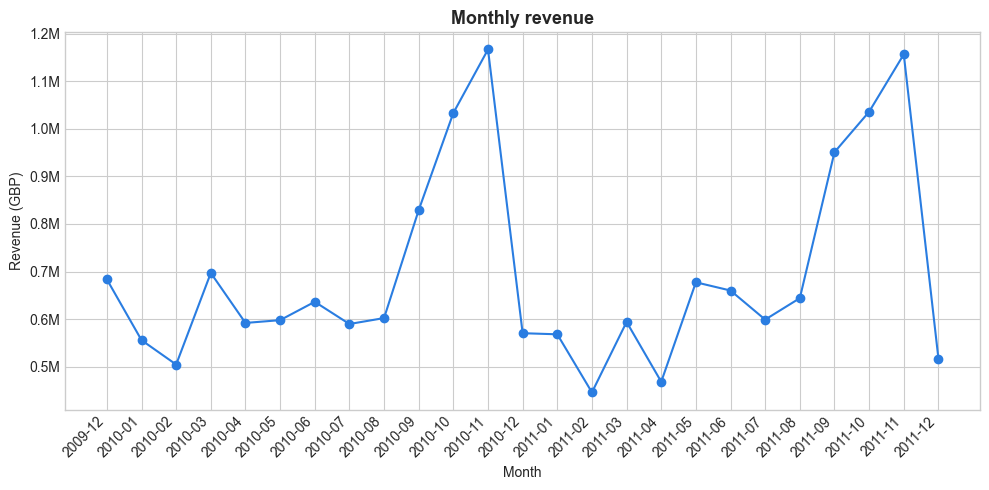

In [7]:
monthly = df.groupby("YearMonth")["Revenue"].sum()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, marker="o", color="#2a7de1")
ax.set_title("Monthly revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Top 10 products by revenue

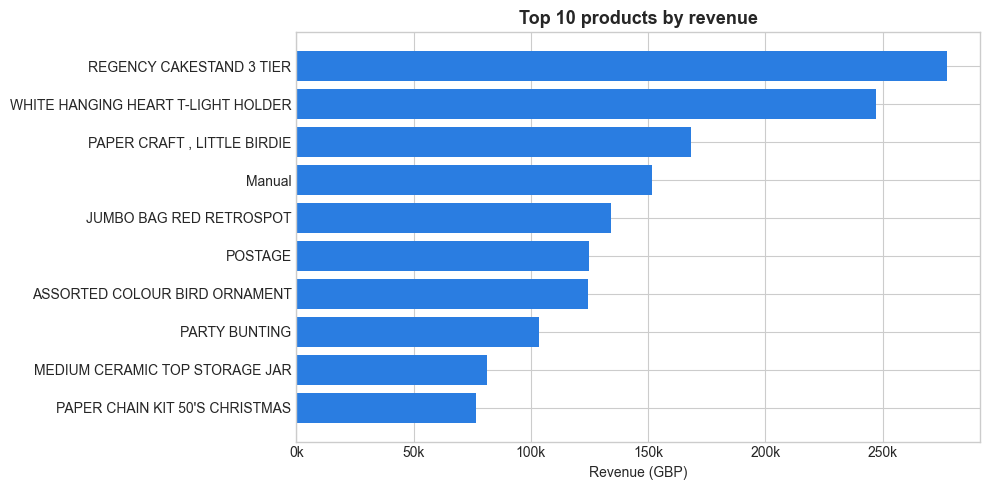

In [8]:
top_products = (df.groupby("Description")["Revenue"].sum()
                  .sort_values(ascending=False).head(10))

fig, ax = plt.subplots()
ax.barh(top_products.index[::-1], top_products.values[::-1], color="#2a7de1")
ax.set_title("Top 10 products by revenue")
ax.set_xlabel("Revenue (GBP)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()

## 7. Revenue by country

The retailer is UK-based, so the UK dominates. We look at the top markets and at the top markets *excluding* the UK to understand export demand.

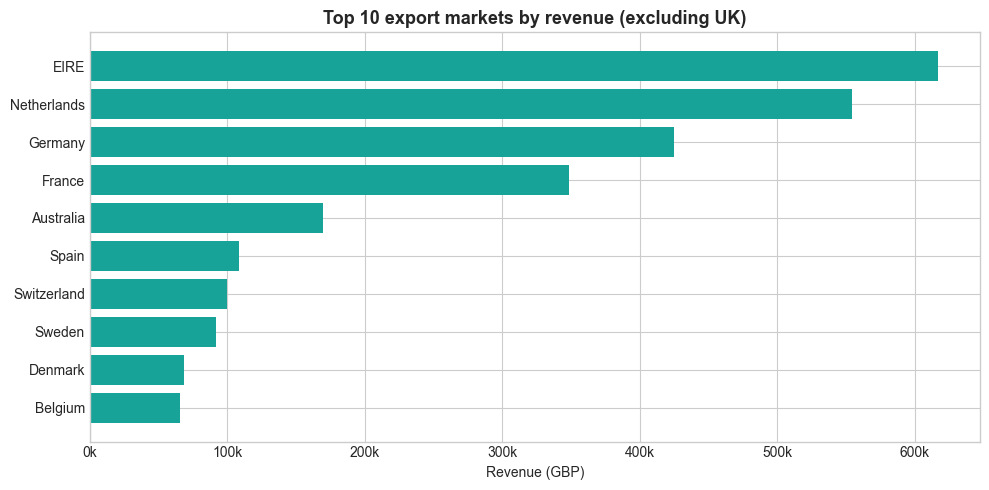

UK share of total revenue: 82.8%


In [9]:
by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_ex_uk = by_country.drop("United Kingdom", errors="ignore").head(10)

fig, ax = plt.subplots()
ax.barh(top_ex_uk.index[::-1], top_ex_uk.values[::-1], color="#17a398")
ax.set_title("Top 10 export markets by revenue (excluding UK)")
ax.set_xlabel("Revenue (GBP)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()

uk_share = by_country.get("United Kingdom", 0) / by_country.sum()
print(f"UK share of total revenue: {uk_share:.1%}")

## 8. Sales by weekday

Which days of the week drive the most revenue? (Useful for staffing / campaign timing.)

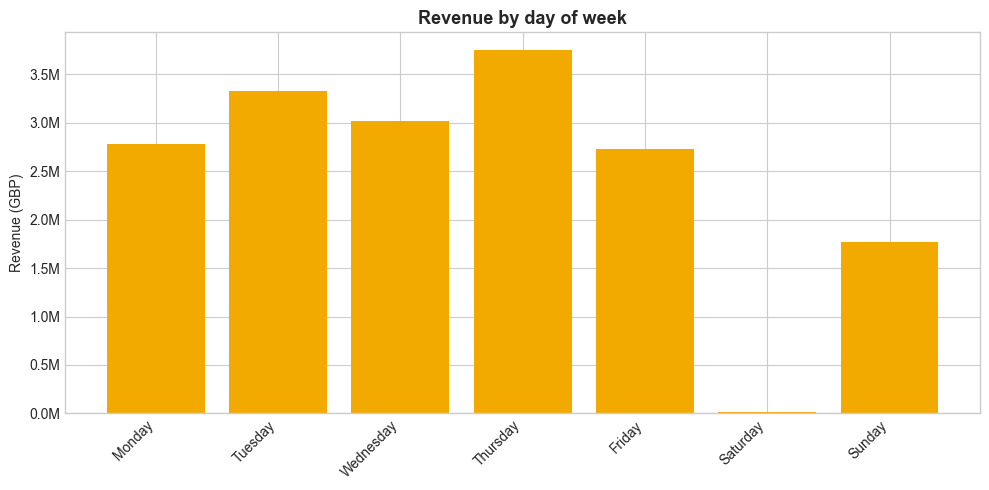

In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_weekday = df.groupby("Weekday")["Revenue"].sum().reindex(weekday_order)

fig, ax = plt.subplots()
ax.bar(by_weekday.index, by_weekday.values, color="#f2a900")
ax.set_title("Revenue by day of week")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Customer behaviour: repeat vs one-time

How much of the business comes from repeat customers? This is a core retention metric.

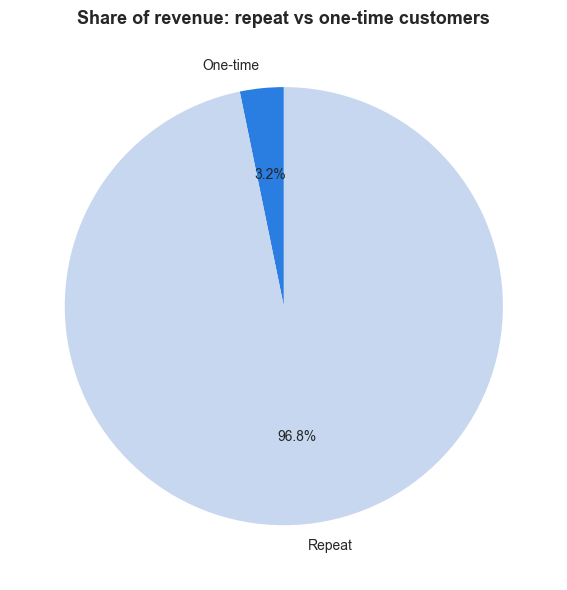

Repeat customers : 4,255 (72.4%)
One-time         : 1,623 (27.6%)


In [11]:
orders_per_customer = df.groupby("Customer ID")["Invoice"].nunique()
repeat = orders_per_customer[orders_per_customer > 1]
one_time = orders_per_customer[orders_per_customer == 1]

# Revenue split by customer type
repeat_ids = set(repeat.index)
df["CustomerType"] = np.where(df["Customer ID"].isin(repeat_ids), "Repeat", "One-time")
rev_by_type = df.groupby("CustomerType")["Revenue"].sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(rev_by_type, labels=rev_by_type.index, autopct="%1.1f%%",
       colors=["#2a7de1", "#c7d7ef"], startangle=90)
ax.set_title("Share of revenue: repeat vs one-time customers")
plt.tight_layout()
plt.show()

print(f"Repeat customers : {len(repeat):,} ({len(repeat)/len(orders_per_customer):.1%})")
print(f"One-time         : {len(one_time):,} ({len(one_time)/len(orders_per_customer):.1%})")

  Insights & conclusions (final, real numbers)

  - Scale: After cleaning (1,067,371 → 779,425 rows; ~27% removed as cancellations, returns, and rows without a customer ID), the dataset holds 779,425 transactions across 36,969 orders and 5,878 customers, totalling £17.4M in revenue over Dec 2009 – Dec 2011. Average order value is £470.
  - Trend: Revenue is highly seasonal — it climbs through autumn and peaks in November (~£1.17M), then drops sharply in the new year.
  - Products: Revenue is concentrated in a few lines — Regency Cakestand 3 Tier (£278k) and White Hanging Heart       
  -Light Holder (£247k) dwarf the long tail (Pareto pattern).
  - Markets: Overwhelmingly domestic — the UK is 82.8% of revenue; top export markets are Ireland, the Netherlands,Germany, and France.
  - Customers: Repeat customers (72% of accounts) generate 96.8% of all revenue — retention is the single biggest lever.